In [6]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import sys
import os
import joblib
from tqdm import tqdm
from pathlib import Path
import networkx as nx
from scipy.spatial.distance import pdist, squareform

from ou_model import forward, backward, score, classify, theoretical_ts
from plotting import plot_speciation_3d, plot_sagd_heatmap_row
from SASNE import SASNE
from RRP import RRP

from adaptive_knn import AdaptiveKNNGraph
from plotting import plot_sagd_heatmap_row
from animations import create_ctd_synchronized_animation, create_animated_embedding

### Toy example - small d and n

In [7]:
torch.manual_seed(123)
d = 2            # Dimension
nsamples_small_n = 6     # Number of trajectories
T_max = 10.0
dt = 0.01
times = np.arange(T_max, 0, -dt)

mu_star, std = torch.tensor([4.0, 4.0]), 1.0

In [9]:
small_n_path_history = []
# Start with pure random noise at t=T 
small_n_x_current = torch.randn(d, nsamples_small_n) 

for t in tqdm(times):
    small_n_path_history.append(small_n_x_current.T.clone().numpy()) 
    small_n_x_current, _ = backward(small_n_x_current, t, dt, mu_star, std)
    
small_n_path_history = np.array(small_n_path_history)

  0%|          | 0/1000 [00:00<?, ?it/s]


TypeError: backward() missing 1 required positional argument: 'model'

Since we can solve the score function analytically, we just need to sample using he backward process
The particles' starting point is the same, the trajectories will remain tangled until the end of the backward process. 
Once speciating takes place, the path commits to a class until the end of the reverse process.
It is at this point that the reverse process starts producing features of the same class. Since we know the exact form of the score function there is not a collapse time.

In [ ]:
Lambda = np.linalg.norm(mu_star)**2 + std**2
t_s = np.log(Lambda) / 2
t_s_idx = next(idx for idx, t in enumerate(times) if round(t, 2) == round(t_s, 2))
print(t_s)

1.7482538


#### Visualize trajectories

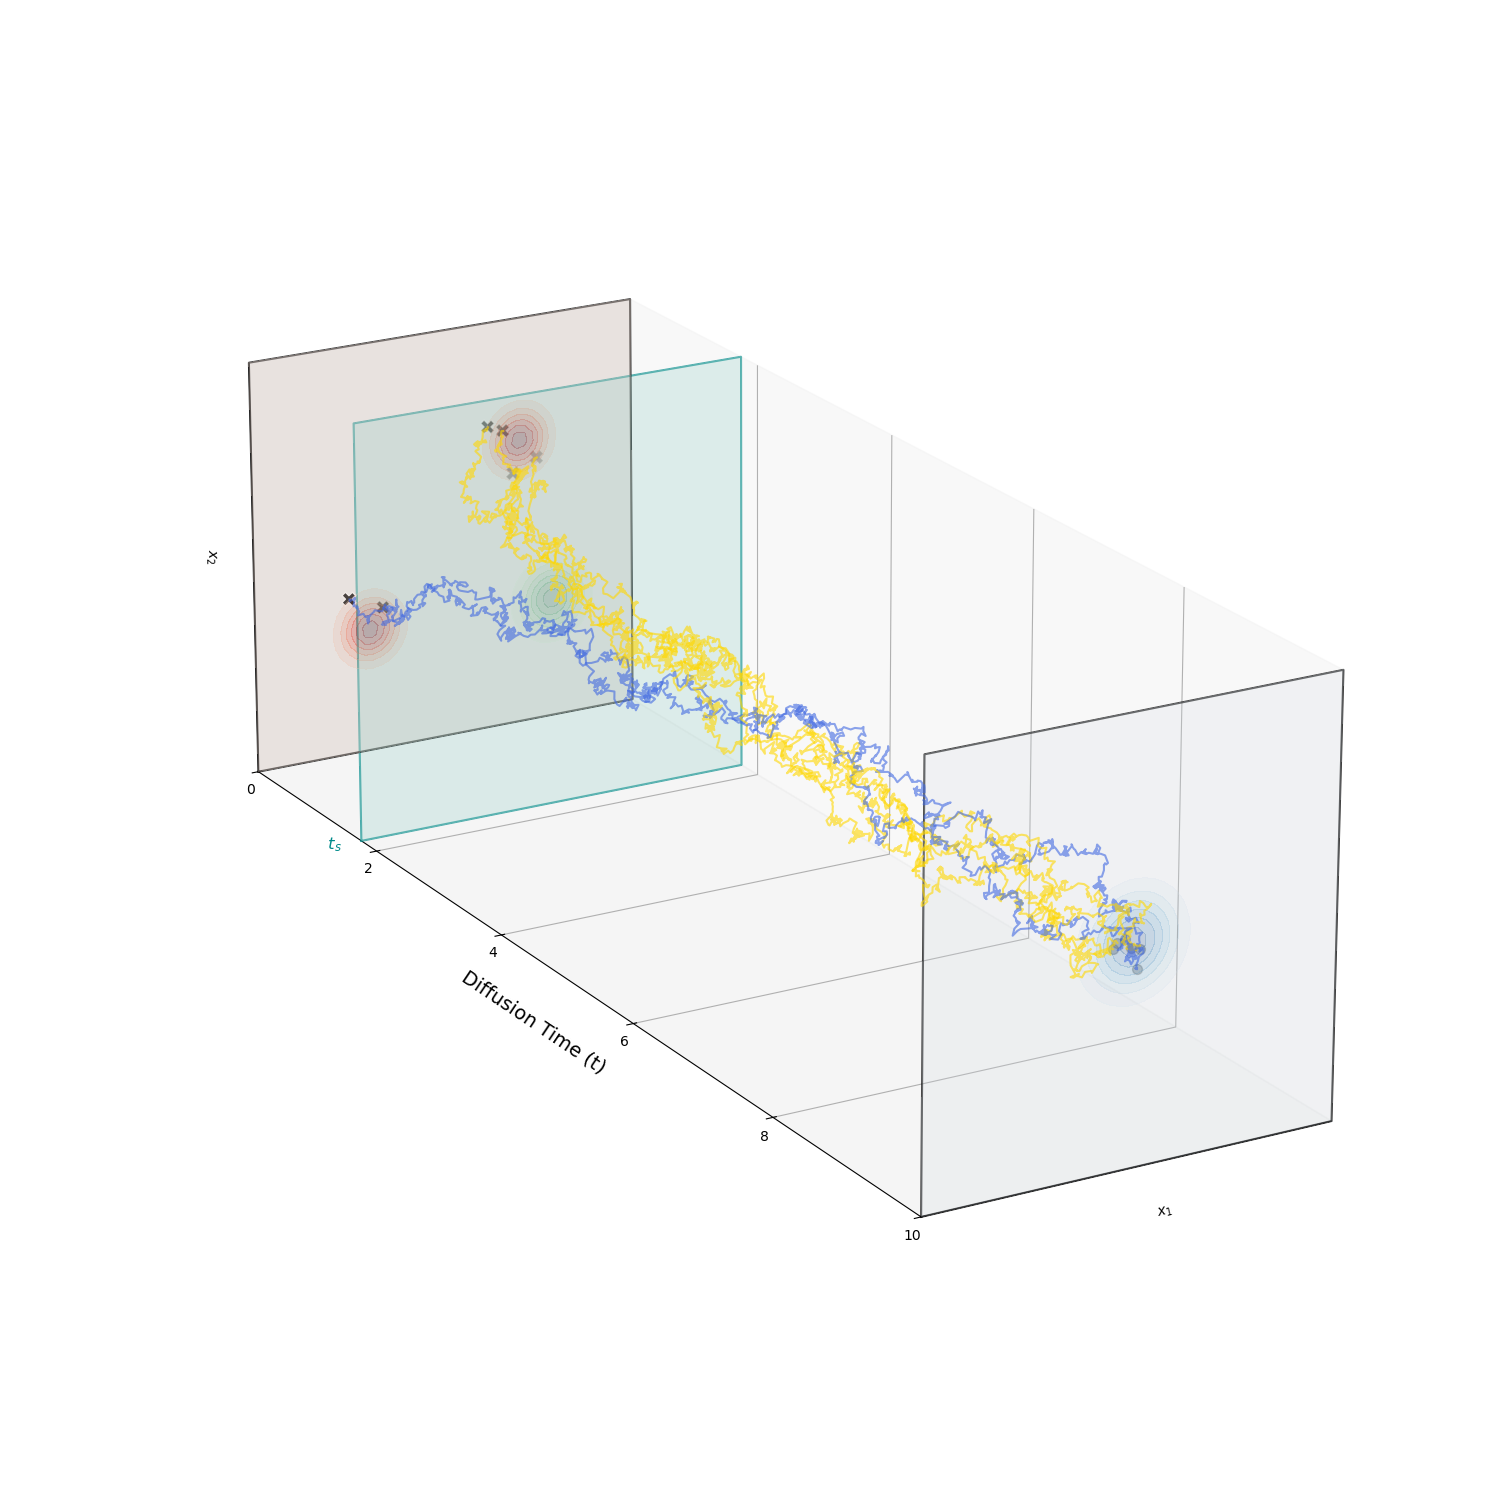

In [ ]:
plot_speciation_3d(
    path_history=small_n_path_history,
    times=times,
    mu_star=mu_star,
    std=std,
    nsamples=nsamples_small_n,
    t_s=t_s,
    save_fig_path='../figures/diffusion_trajectories.png'
)

### Knn graph from data at different time steps

In [10]:
d=2
path = Path('../data/exp_01')
loaded_data = joblib.load(path / f"D{d}_N1000_T10/history.jbl")
large_n_path_history = loaded_data["history"]
time_snaps = list(large_n_path_history.keys())
tsm, ts_idx = theoretical_ts(mu_star, std, times)
ts_idx = np.argmin(np.abs(time_snaps - t_s))
X_T = torch.as_tensor(large_n_path_history[0], dtype=mu_star.dtype).T
node_labels = classify(X_T, mu_star)
colors = node_labels.numpy().flatten()
knn_objs = []

for idx in [0, ts_idx, -1]:
    knn_obj = AdaptiveKNNGraph(large_n_path_history[time_snaps[idx]], inject_edges=True, kernel='gaussian')
    W = knn_obj.compute_W()
    k = knn_obj.k
    knn_objs.append((W, k))

NameError: name 't_s' is not defined

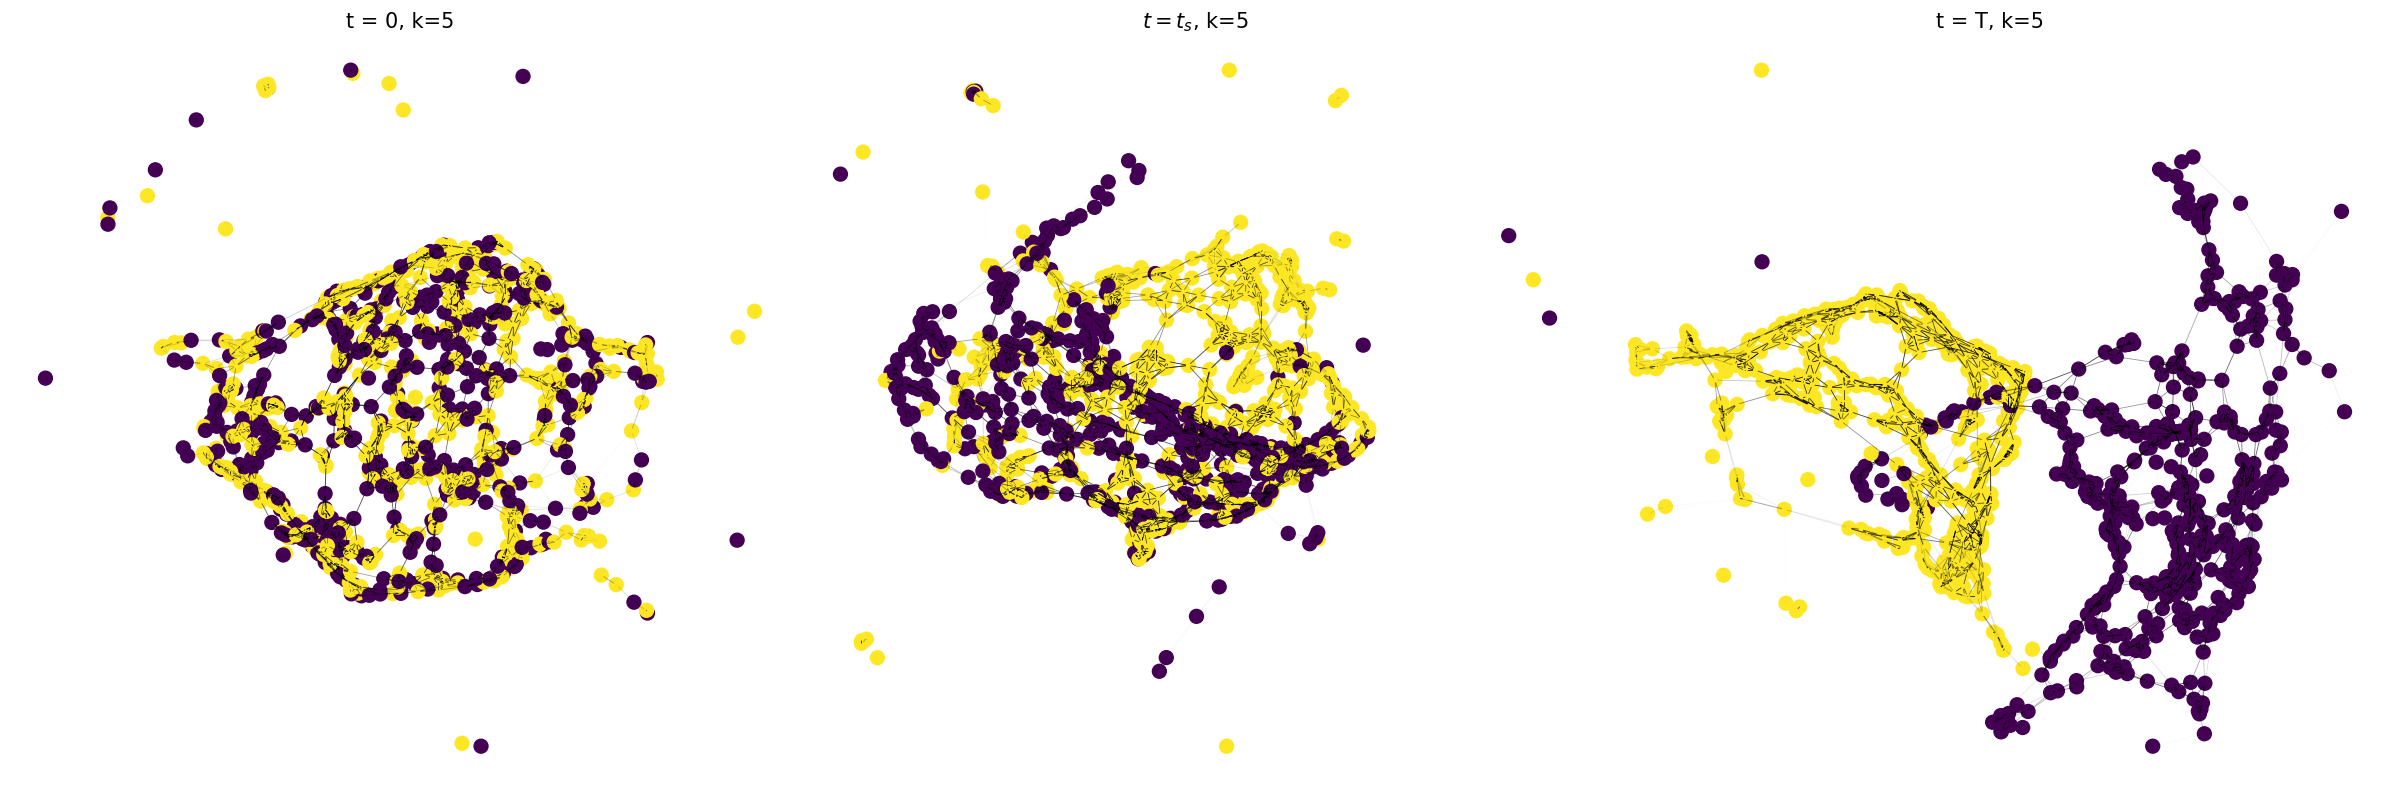

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
titles = ["t = 0", "$t = t_s$", "t = T"]
for i, obj in enumerate(knn_objs):
    W, k = obj
    G = nx.from_numpy_array(W)
    pos = nx.spring_layout(G, seed=42, k=0.15) 
    ax = axes[i]
    nx.draw_networkx_nodes(G, pos, node_size=100, node_color=colors, ax=ax)
    edges = G.edges(data=True)
    for u, v, d in edges:
        ax.annotate("", xy=pos[v], xycoords='data', xytext=pos[u], textcoords='data',
                    arrowprops=dict(arrowstyle="-", color="black", alpha=min(max(d['weight'], 0), 1),lw=0.6))
    ax.set_title(titles[i] + f", k={k}", fontsize=15)
    ax.axis('off')
plt.tight_layout()
plt.show()

### SASNE projection of the SAGS distance matrix for higher dimensions

In [20]:
ds = sorted([int(i.name.rsplit('_')[0].rsplit('D')[1]) for i in path.iterdir() if 'D' in i.name ])
# ds = [2]
last_frames = []
for d in ds:
    embeddings_data = joblib.load(path / f"D{d}_N1000_T10/SASNE.jbl")
    ld = joblib.load(path / f"D{d}_N1000_T10/history.jbl")
    breakpoints = joblib.load(path / f"D{d}_N1000_T10/clusters.jbl")
    SAGD_dist_matrix = joblib.load(path / f"D{d}_N1000_T10/SAGD.jbl")

    snaps = ld['params']['times_snapshots']
    t_s_i = ld['params']['ts_theoretical']
    t_sagd_i = breakpoints[0]
    save_basename = "../figures/sasne_animation_D{}".format(d)
    embeddings = embeddings_data["embedding"]
    sasne_dim = embeddings_data["dim"]

    create_animated_embedding(embedding=embeddings, 
                              time_snaps=snaps, 
                              d=d, 
                              tsagd_idx=t_sagd_i, 
                              save_path=save_basename,
                              dim=sasne_dim)
    last_frames.append((d, embeddings, snaps, t_sagd_i))

# t_min = min(min(snaps) for _, _, snaps, _ in last_frames)
# t_max = max(max(snaps) for _, _, snaps, _ in last_frames)

# centered = []
# for d, embeddings, snaps, t_sagd_i in last_frames:
#     mid = 0.5 * (embeddings.min(axis=0) + embeddings.max(axis=0))
#     centered.append((d, embeddings - mid, snaps, t_sagd_i))

# half_range = max(
#     max(np.abs(e[:, 0]).max(), np.abs(e[:, 1]).max())
#     for _, e, _, _ in centered
# ) + 1.5

# fig, axes = plt.subplots(1, len(ds), figsize=(6 * len(ds), 6))
# if len(ds) == 1:
#     axes = [axes]
# sc = None
# for ax, (d, embeddings, snaps, t_sagd_i) in zip(axes, centered):
#     n_frames = len(embeddings)
#     sc = ax.scatter(embeddings[:, 0], embeddings[:, 1],
#                     c=snaps, cmap='viridis_r',
#                     s=25, alpha=0.8, vmin=t_min, vmax=t_max)
#     ax.set_xlim(-half_range, half_range)
#     ax.set_ylim(-half_range, half_range)
#     ax.set_aspect('equal')
#     ax.set_title(f"d={d}", fontsize=14)
#     ax.set_xlabel("SASNE1")
#     ax.set_ylabel("SASNE2")

#     def _pointer(ax, idx, label, color, offset):
#         ax.annotate(label,
#                     xy=(embeddings[idx, 0], embeddings[idx, 1]),
#                     xytext=offset, textcoords='offset points',
#                     arrowprops=dict(arrowstyle='->', color=color, lw=2),
#                     bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.8),
#                     fontsize=10, fontweight='bold', color=color, zorder=10)

#     _pointer(ax, 0, '$t=T$', 'red', (-80, 40))
#     _pointer(ax, t_sagd_i, '$t=t_{\\mathrm{SAGD}}$', 'darkcyan', (40, 40))
#     _pointer(ax, n_frames - 1, '$t=0$', 'orange', (20, -40))

# fig.tight_layout(rect=[0, 0, 0.93, 1])
# cbar_ax = fig.add_axes([0.94, 0.15, 0.012, 0.7])
# cbar = fig.colorbar(sc, cax=cbar_ax)
# cbar.set_label('t', rotation=0, labelpad=10)
# plt.savefig('../figures/sasne_last_frames_row.png', bbox_inches='tight')
# plt.show()

min outlier-outlier distance: 10.40
min outlier-cluster  distance: 22.33


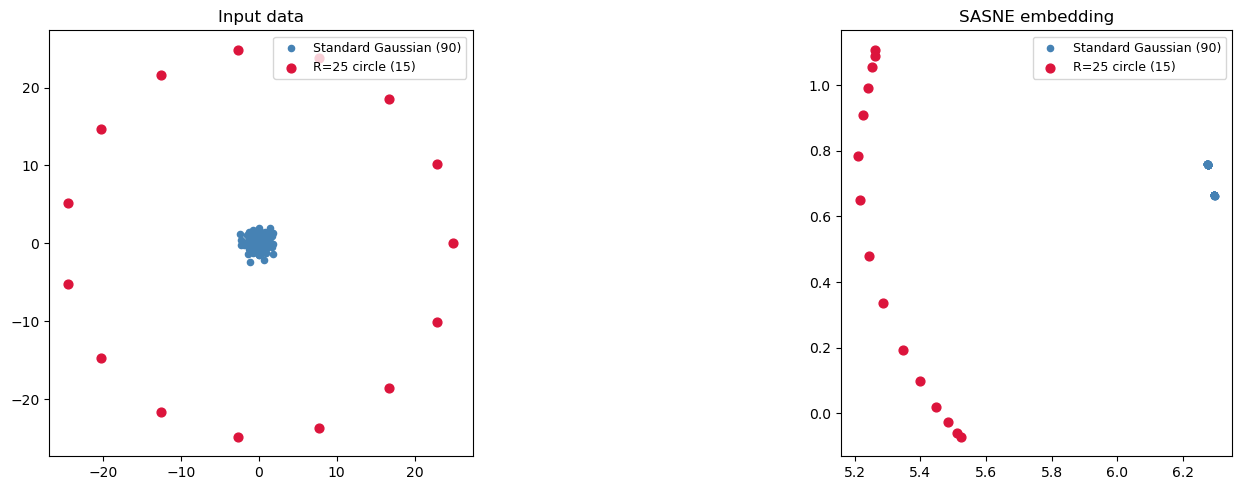

Gaussian-point cluster sizes (top 2): [45, 45]


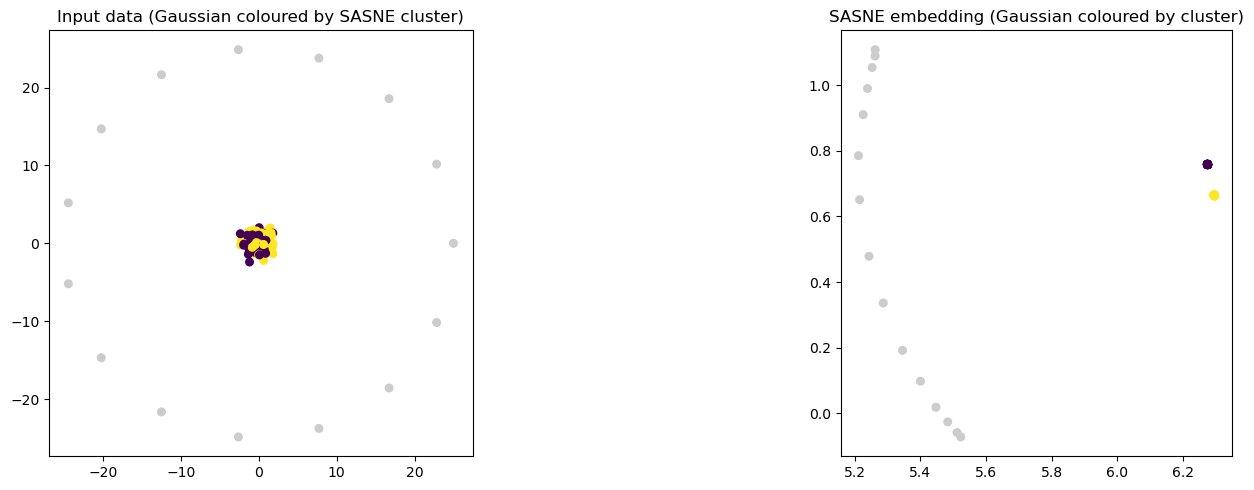

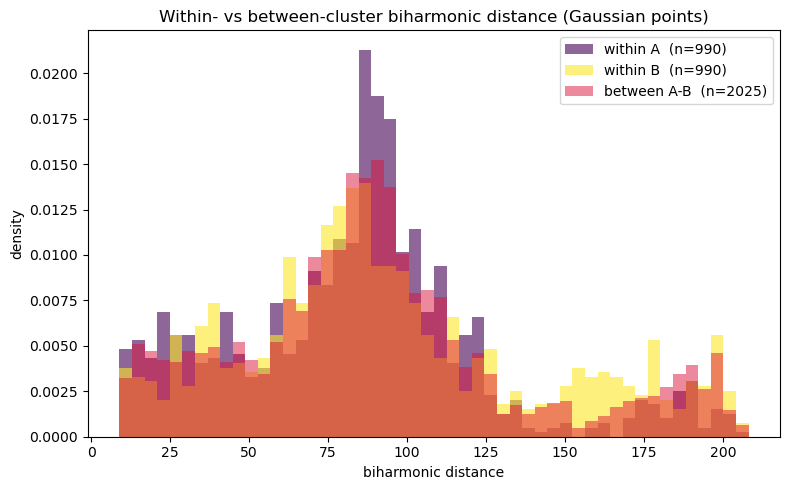

In [13]:
# SASNE sanity-check on synthetic data:
#   - 90 points from a standard 2D Gaussian
#   - 10 outliers placed on a circle of radius 25 so that every pairwise
#     distance (outlier-outlier and outlier-cluster) is > 10.
from sklearn.manifold import TSNE

R = 25.0
num_outliers = 15
cluster_size = 90

rng_sanity = np.random.default_rng(0)
cluster_pts = rng_sanity.standard_normal(size=(cluster_size, 2))
angles = np.linspace(0, 2 * np.pi, num_outliers, endpoint=False)
outlier_pts = np.stack([R * np.cos(angles), R * np.sin(angles)], axis=1)

data_sanity = np.vstack([cluster_pts, outlier_pts])
labels_sanity = np.concatenate([np.zeros(cluster_size, dtype=int), np.ones(num_outliers, dtype=int)])

# Quick check that the distance constraints hold.
D_sanity = squareform(pdist(data_sanity))
min_oo = D_sanity[cluster_size:, cluster_size:][np.triu_indices(num_outliers, k=1)].min()
min_oc = D_sanity[:cluster_size, cluster_size:].min()
print(f"min outlier-outlier distance: {min_oo:.2f}")
print(f"min outlier-cluster  distance: {min_oc:.2f}")

embedding_sanity, Z_sanity, W_sanity = SASNE(data_sanity, n_components=2)

# Plain t-SNE on the raw data, using the same perplexity as SASNE for comparison.
n_total = len(data_sanity)
tsne_embedding = TSNE(
    n_components=2,
    perplexity=0.9 * n_total,
    init='pca',
    random_state=0,
).fit_transform(data_sanity)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, pts, title in [
    (axes[0], data_sanity, "Input data"),
    (axes[1], embedding_sanity, "SASNE embedding")
    # (axes[2], tsne_embedding, "t-SNE embedding"),
]:
    ax.scatter(pts[labels_sanity == 0, 0], pts[labels_sanity == 0, 1],
               s=20, c='steelblue', label=f'Standard Gaussian ({cluster_size})')
    ax.scatter(pts[labels_sanity == 1, 0], pts[labels_sanity == 1, 1],
               s=40, c='crimson', label=f'R=25 circle ({num_outliers})')
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# --- Identify two clusters in the SASNE embedding among the Gaussian points only ---
# Same logic as in the SAGD cell: threshold pairwise distances, take connected
# components, keep the two largest. Outliers are excluded from the clustering.
emb_gauss = embedding_sanity[:cluster_size]
emb_dists_g = squareform(pdist(emb_gauss))
emb_adj_g = (emb_dists_g < 0.01).astype(int)
np.fill_diagonal(emb_adj_g, 0)
H_g = nx.from_numpy_array(emb_adj_g)
components_g = sorted(nx.connected_components(H_g), key=len, reverse=True)
top_two_g = components_g[:2]
print(f"Gaussian-point cluster sizes (top 2): {[len(c) for c in top_two_g]}")

# Build a colour array: outliers grey, gaussian points in viridis(0/1) per cluster.
grey = np.array([0.8, 0.8, 0.8, 1.0])
palette_g = plt.cm.viridis(np.linspace(0, 1, max(len(top_two_g), 2)))
point_colors = np.tile(grey, (len(data_sanity), 1))
gauss_cluster_of = {}
for cid, comp in enumerate(top_two_g):
    for node in comp:
        point_colors[node] = palette_g[cid]
        gauss_cluster_of[node] = cid

# --- Plot 2: input data and SASNE embedding, gaussian points coloured by cluster ---
fig2, axes2 = plt.subplots(1, 2, figsize=(18, 5))
for ax, pts, title in [
    (axes2[0], data_sanity, "Input data (Gaussian coloured by SASNE cluster)"),
    (axes2[1], embedding_sanity, "SASNE embedding (Gaussian coloured by cluster)"),
]:
    ax.scatter(pts[:, 0], pts[:, 1], s=30, c=point_colors)
    ax.set_title(title)
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()

# --- Plot 3: within/between cluster biharmonic distance distributions ---
# Biharmonic distance is ||Z_i - Z_j||, i.e. the Euclidean distance in the
# symbiharmonic embedding. Compare its distribution within each cluster vs across.
A_idx = np.array(sorted(top_two_g[0]))
B_idx = np.array(sorted(top_two_g[1]))
bihar = squareform(pdist(Z_sanity))
within_A = bihar[np.ix_(A_idx, A_idx)][np.triu_indices(len(A_idx), k=1)]
within_B = bihar[np.ix_(B_idx, B_idx)][np.triu_indices(len(B_idx), k=1)]
between_AB = bihar[np.ix_(A_idx, B_idx)].ravel()

fig3, ax3 = plt.subplots(figsize=(8, 5))
bins = np.histogram_bin_edges(np.concatenate([within_A, within_B, between_AB]), bins=50)
ax3.hist(within_A, bins=bins, alpha=0.6, density=True,
         color=palette_g[0], label=f'within A  (n={len(within_A)})')
ax3.hist(within_B, bins=bins, alpha=0.6, density=True,
         color=palette_g[1], label=f'within B  (n={len(within_B)})')
ax3.hist(between_AB, bins=bins, alpha=0.5, density=True,
         color='crimson', label=f'between A-B  (n={len(between_AB)})')
ax3.set_xlabel('biharmonic distance')
ax3.set_ylabel('density')
ax3.set_title('Within- vs between-cluster biharmonic distance (Gaussian points)')
ax3.legend()
plt.tight_layout()
plt.show()

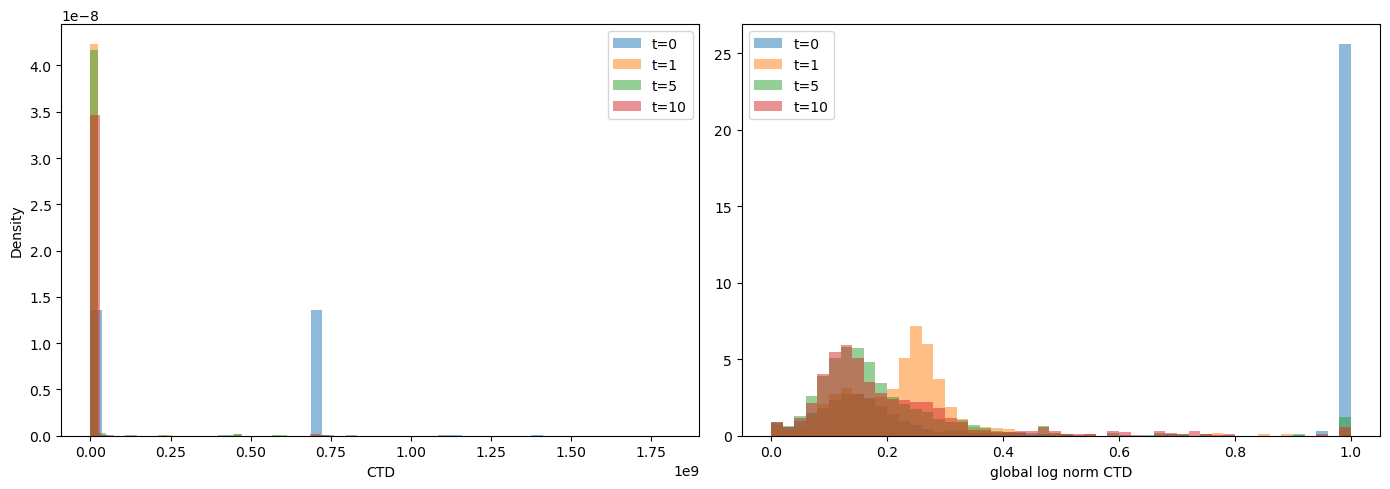

In [20]:
d=2
CTDs= joblib.load(path / f"D{d}_N1000_T10/CTDs.jbl")
t_values = [0, 1, 5, 10]
temp = []
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ctds_dict = CTDs['CTDs']
for t in t_values:
    ctds = ctds_dict[t]['ctds']
    axes[0].hist(ctds, bins=50, alpha=0.5, label=f't={t}', density=True)
    # Global Log scale
    norm_ctds = ctds_dict[t]['norm_ctds']
    axes[1].hist(norm_ctds, bins=50, alpha=0.5, label=f't={t}', density=True)
axes[0].set_xlabel('CTD')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[1].set_xlabel('global log norm CTD')
axes[1].legend()
plt.savefig('norm.png')
plt.tight_layout()
plt.show()

In [9]:
SAGD_dist_matrix_list = []
for d in ds:
    loaded_data = joblib.load(path / f"D{d}_N1000_T10/history.jbl")
    CTDs= joblib.load(path / f"D{d}_N1000_T10/CTDs.jbl")
    T = loaded_data['params']['T']
    n_steps = loaded_data['params']['n_steps']
    dt = T / n_steps
    time_snaps = loaded_data['params']['times_snapshots']
    t_s = loaded_data['params']["ts_theoretical"]
    ts_idx = np.argmin(np.abs(time_snaps - t_s))
    SAGD_dist_matrix = joblib.load(path / f"D{d}_N1000_T10/SAGD.jbl")
    SAGD_dist_matrix_list.append((SAGD_dist_matrix, time_snaps,  t_s, ts_idx))

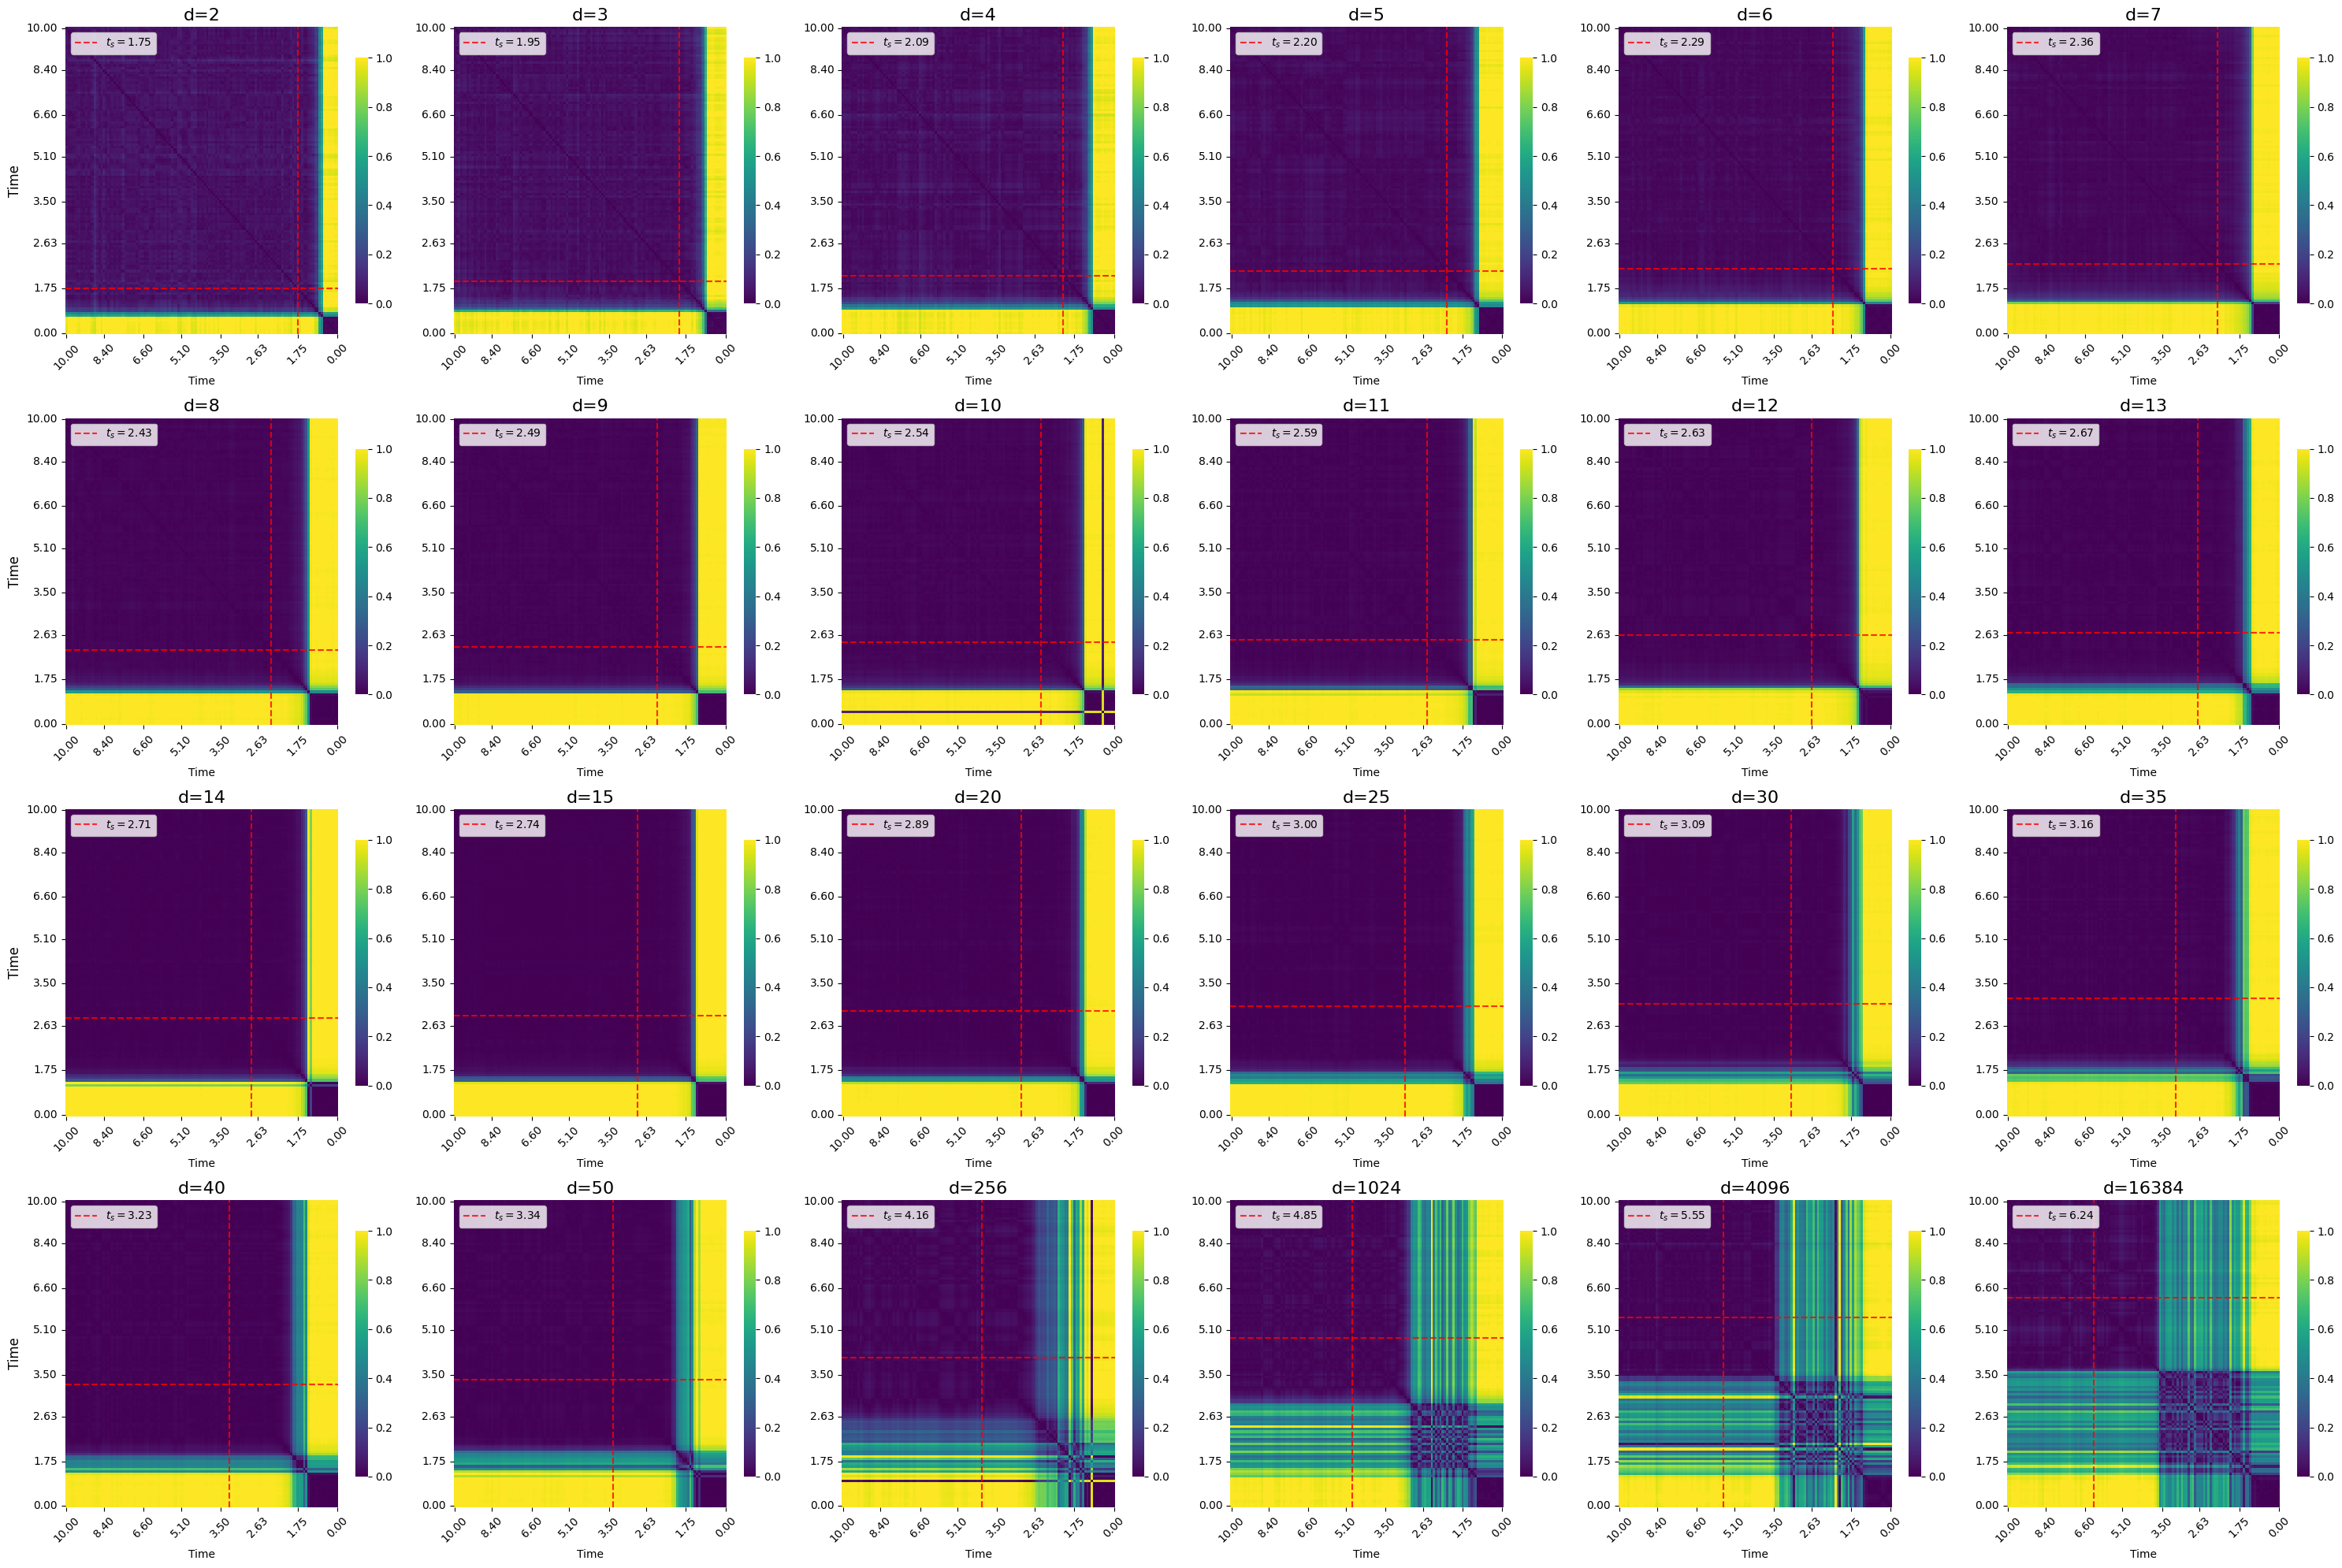

In [10]:
plot_sagd_heatmap_row(
        W_list=[matrix for matrix, *_ in SAGD_dist_matrix_list],
        d_list=ds,
        time_snaps_vector_list=[time_snaps for _, time_snaps, *_ in SAGD_dist_matrix_list],
        ts_tuple_list=[(t_s, ts_idx) for *_, t_s, ts_idx in SAGD_dist_matrix_list],
        save_fig_path='sagd_dm.png'
)

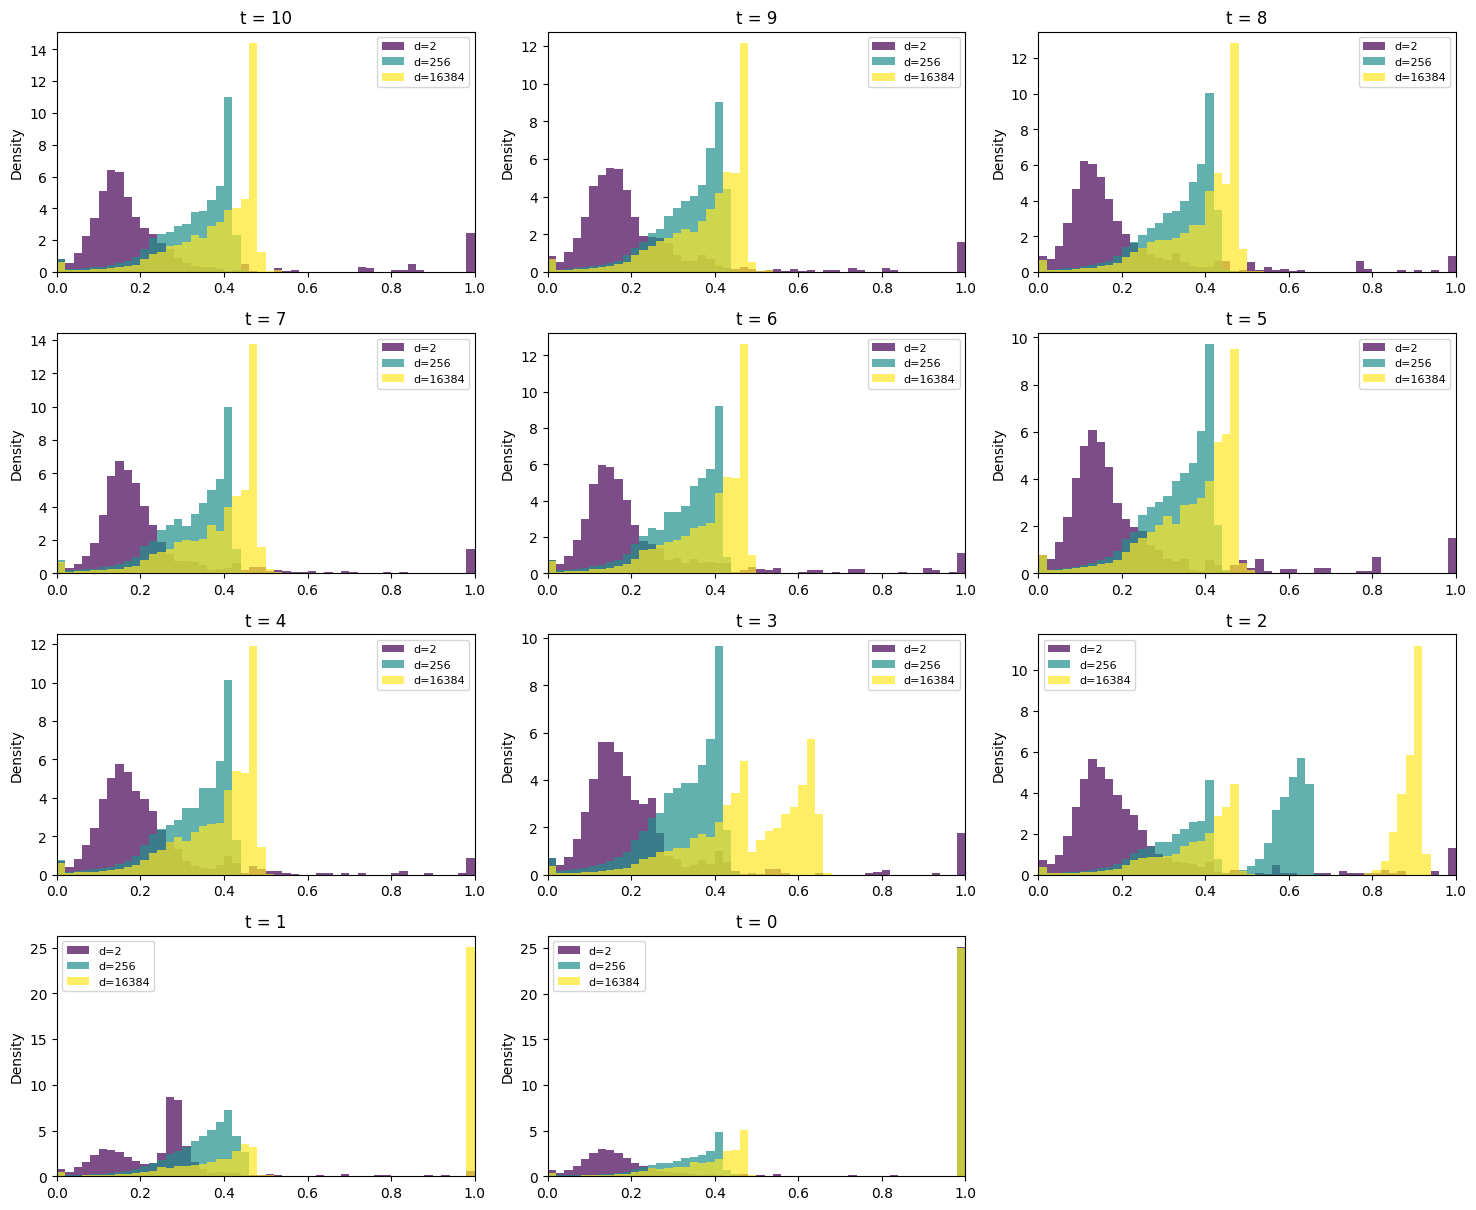

In [11]:
ds = [2, 256, 16384] 
colors = plt.cm.viridis(np.linspace(0, 1, len(ds)))

data = {}
for d in ds:
    data[d] = joblib.load(path / f"D{d}_N1000_T10/CTDs.jbl")
    
shared_bins = np.linspace(0, 1, 51)
t_subset = sorted([t for t in CTDs['CTDs'].keys() if 0.5 <= t <= 2.0])
n = len(t_subset)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3))
axes = axes.flatten()
for i, t in enumerate(range(0, 11, 1)[::-1]):
    for idx, d in enumerate(ds):
        axes[i].hist(data[d]['CTDs'][t]['norm_ctds'], bins=shared_bins, alpha=0.7, density=True, 
                    color=colors[idx], label=f'd={d}')
        
        axes[i].set_title(f't = {round(t, 3)}')
        axes[i].set_ylabel('Density')
        axes[i].set_xlim(0, 1)
        axes[i].legend(fontsize=8)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
save_path = 'exmp.png'
if save_path:
    plt.savefig(save_path)
plt.show()

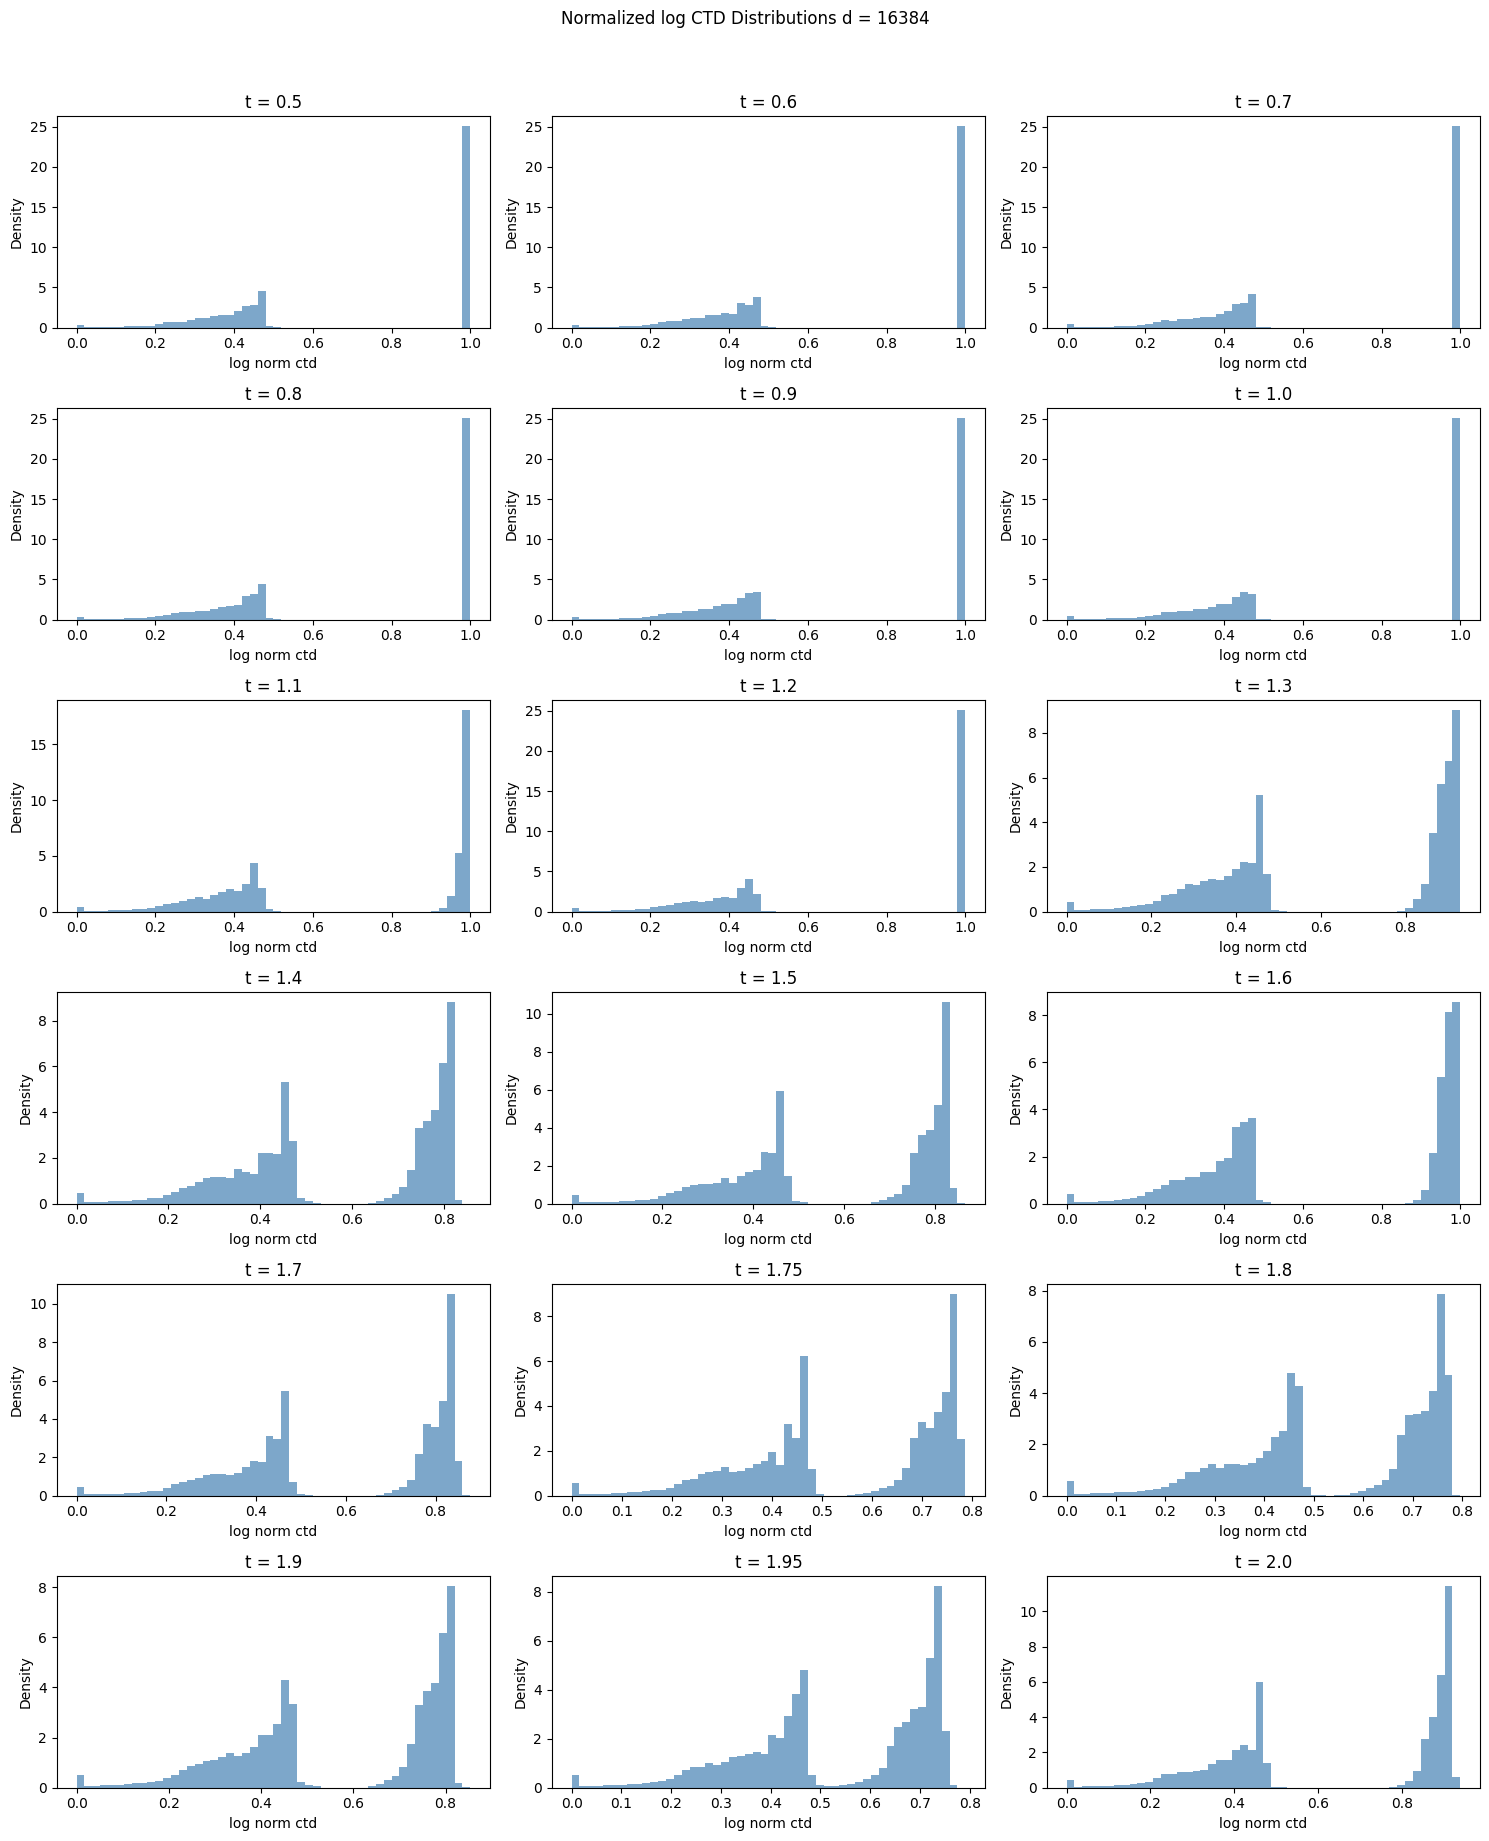

In [12]:
d = 16384
CTDs = data[d]
t_values = [t for t in CTDs['CTDs'].keys() if 0.5 <= t <= 2.0]
t_values = sorted(t_values)

n = len(t_values)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3))
axes = axes.flatten()

for i, t in enumerate(t_values):
    log_ctds = np.array(CTDs['CTDs'][t]['norm_ctds'])
    axes[i].hist(log_ctds, bins=50, density=True, color='steelblue', alpha=0.7)
    axes[i].set_title(f't = {round(t, 3)}')
    axes[i].set_xlabel('log norm ctd')
    axes[i].set_ylabel('Density')

# hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Normalized log CTD Distributions d = {d}', y=1.02)
plt.savefig('norm_ctds.png')
plt.tight_layout()
plt.show()

In [13]:
d = 16384
CTDs = joblib.load(path / f"D{d}_N1000_T10/CTDs.jbl")
loaded_data = joblib.load(path / f"D{d}_N1000_T10/history.jbl")
SAGD_dist_matrix = joblib.load(path / f"D{d}_N1000_T10/SAGD.jbl")
time_snaps = loaded_data['params']['times_snapshots']
t_s = loaded_data['params']["ts_theoretical"]
ts_idx = np.argmin(np.abs(time_snaps - t_s))
ctds = [CTDs['CTDs'][t]['norm_ctds'] for t in time_snaps]

create_ctd_synchronized_animation(
    d=16384,
    ctds_list=ctds,
    time_snaps=time_snaps,    
    ts=t_s,                  
    ts_idx=ts_idx,           
    SAGD_dist_matrix=SAGD_dist_matrix, 
    save_path='D16384_ctds_progression.gif'
)